# RoadSafe India — Vehicle Exposure Data

## Objective

This notebook investigates the availability and suitability of State/UT-level
vehicle registration data as an additional proxy for road-traffic exposure.

The candidate source is the Vahan Public Dashboard of the Ministry of Road
Transport & Highways, Government of India.

## Research Variable

Primary variable:

- Total vehicle registrations by State/UT

Derived variable:

- Vehicles per 1,000 projected population

## Intended Use

Vehicle registrations will be evaluated as an explanatory variable for
State/UT-level differences in reported accidents and fatalities.

## Important Limitation

Vehicle registrations represent the registered vehicle fleet and do not
directly measure road usage, vehicle-kilometres travelled, traffic volume or
time spent on roads.

In [45]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np




In [3]:
# Locate the Vahan vehicle-registration report

project_root = Path.cwd().parent

vehicle_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_registrations_2024.csv"
)

print("Vehicle data path:")
print(vehicle_path)

print("\nFile exists:", vehicle_path.exists())

Vehicle data path:
d:\Data Science\Projects\RoadSafe-India\data\research\vehicle_registrations_2024.csv

File exists: True


In [4]:
# Read the raw CSV without assuming a clean header

vehicle_raw = pd.read_csv(
    vehicle_path,
    header=None
)

print("Shape:", vehicle_raw.shape)

display(vehicle_raw.head(10))

Shape: (38, 2)


,0,1
0,"State Wise Data for AN, AP, AR, AS, BR, CH, CG...",Total Consolidated
1,Andaman & Nicobar Island,8460
2,Andhra Pradesh,911747
3,Arunachal Pradesh,36796
4,Assam,629458
5,Bihar,1395212
6,Chandigarh,46398
7,Chhattisgarh,714000
8,Delhi,711069
9,Goa,84300


In [5]:
# Display rows containing "State" or "Total Consolidated"

for index, row in vehicle_raw.iterrows():

    row_text = " | ".join(
        str(value)
        for value in row.tolist()
    )

    if (
        "State" in row_text
        or "Total Consolidated" in row_text
    ):
        print(index, ":", row_text)

0 : State Wise Data for AN, AP, AR, AS, BR, CH, CG, DL, GA, GJ, HR, HP, JK, JH, KA, KL, LA, LD, MP, MH, MN, ML, MZ, NL, OR, PY, PB, RJ, SK, TN, TG, TR, DD, UP, UK, WB (2024)\n\nState | Total Consolidated


In [6]:
vehicle_raw.head(10)

,0,1
0,"State Wise Data for AN, AP, AR, AS, BR, CH, CG...",Total Consolidated
1,Andaman & Nicobar Island,8460
2,Andhra Pradesh,911747
3,Arunachal Pradesh,36796
4,Assam,629458
5,Bihar,1395212
6,Chandigarh,46398
7,Chhattisgarh,714000
8,Delhi,711069
9,Goa,84300


In [15]:
# Clean Vahan vehicle-registration data

# Row 0 contains the report title/header. State/UT records begin from row 1.

vehicle_clean = vehicle_raw.iloc[1:].copy()

# Keep only the two relevant columns
vehicle_clean = vehicle_clean.iloc[:, [0, 1]]

# Rename columns
vehicle_clean.columns = [
    "state",
    "vehicle_registrations_2024"
]

# Clean State/UT names
vehicle_clean["state"] = (
    vehicle_clean["state"]
    .astype("string")
    .str.strip()
)

# Convert vehicle registrations to numeric
vehicle_clean["vehicle_registrations_2024"] = (
    pd.to_numeric(
        vehicle_clean["vehicle_registrations_2024"],
        errors="coerce"
    )
)

# Remove invalid rows
vehicle_clean = vehicle_clean[
    vehicle_clean["state"].notna()
    & vehicle_clean["vehicle_registrations_2024"].notna()
].copy()


# Remove aggregate Total row

vehicle_clean = vehicle_clean[
    vehicle_clean["state"].str.lower() != "total"
].copy()


# Reset index
vehicle_clean = vehicle_clean.reset_index(drop=True)

# Check result

print("Cleaned vehicle dataset shape:")
print(vehicle_clean.shape)

print("\nNumber of State/UTs:")
print(vehicle_clean["state"].nunique())

display(vehicle_clean.tail(10))

Cleaned vehicle dataset shape:
(36, 2)

Number of State/UTs:
36


,state,vehicle_registrations_2024
26,Punjab,705747
27,Rajasthan,1653718
28,Sikkim,11671
29,Tamil Nadu,1953405
30,Telangana,1026491
31,Tripura,63665
32,UT of DNH and DD,24202
33,Uttar Pradesh,3757843
34,Uttarakhand,281788
35,West Bengal,1184916


In [16]:
# Validate State/UT coverage

print(
    "Number of rows:",
    len(vehicle_clean)
)

print(
    "Unique State/UTs:",
    vehicle_clean["state"].nunique()
)

print(
    "Duplicate State/UTs:",
    vehicle_clean["state"].duplicated().sum()
)


print("\nDuplicate State/UT rows:")

display(
    vehicle_clean[
        vehicle_clean["state"].duplicated(
            keep=False
        )
    ]
)

Number of rows: 36
Unique State/UTs: 36
Duplicate State/UTs: 0

Duplicate State/UT rows:


,state,vehicle_registrations_2024


In [17]:
# Inspect important State/UT names

important_states = [
    "Andaman & Nicobar Island",
    "Delhi",
    "Jammu and Kashmir",
    "Ladakh",
    "Odisha",
    "Uttarakhand"
]

display(
    vehicle_clean[
        vehicle_clean["state"].isin(
            important_states
        )
    ]
)

,state,vehicle_registrations_2024
0,Andaman & Nicobar Island,8460
7,Delhi,711069
12,Jammu and Kashmir,179387
16,Ladakh,5437
24,Odisha,810893
34,Uttarakhand,281788


In [18]:
# Save cleaned vehicle-registration dataset

clean_vehicle_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_registrations_2024_clean.csv"
)

vehicle_clean.to_csv(
    clean_vehicle_path,
    index=False
)

print(
    "Clean vehicle dataset saved to:"
)

print(clean_vehicle_path)

Clean vehicle dataset saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\vehicle_registrations_2024_clean.csv


In [19]:
# Load RoadSafe master dataset

master_path = (
    project_root
    / "data"
    / "processed"
    / "master_state_analysis_2024.csv"
)

df = pd.read_csv(master_path)

print("RoadSafe master dataset loaded.")
print("Shape:", df.shape)

display(df.head())

RoadSafe master dataset loaded.
Shape: (36, 26)


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,five_year_average_fatalities,fatality_years_available,accident_change_2020_to_2024,accident_percent_change_2020_to_2024,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,8000.2,5,48.0,0.246040,1307.0,18.567978,9.0,8.0,11.0,8.0
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,138.2,5,143.0,106.716418,95.0,130.136986,27.0,27.0,24.0,18.0
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,3061.2,5,1253.0,18.999242,722.0,27.462914,16.0,18.0,19.0,22.0
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,8295.4,5,2971.0,34.390554,2648.0,39.528288,14.0,7.0,33.0,25.0
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,5784.4,5,3201.0,27.462251,2339.0,50.781589,11.0,11.0,9.0,2.0


In [20]:
# Compare vehicle data with RoadSafe master data

roadsafe_states = set(
    df["state"].dropna()
)

vehicle_states = set(
    vehicle_clean["state"].dropna()
)


print("States only in RoadSafe:")
print(
    sorted(
        roadsafe_states - vehicle_states
    )
)


print("\nStates only in Vahan:")
print(
    sorted(
        vehicle_states - roadsafe_states
    )
)

States only in RoadSafe:
['Andaman & Nicobar Islands', 'Dadra & Nagar Haveli and Daman & Diu', 'Jammu & Kashmir', 'N.C.T of Delhi']

States only in Vahan:
['Andaman & Nicobar Island', 'Delhi', 'Jammu and Kashmir', 'UT of DNH and DD']


In [21]:
# Standardize Vahan State/UT names for merging

vehicle_name_mapping = {

    "Andaman & Nicobar Island":
        "Andaman & Nicobar Islands",

    "UT of DNH and DD":
        "Dadra & Nagar Haveli and Daman & Diu",

    "Jammu and Kashmir":
        "Jammu & Kashmir",

    "Delhi":
        "N.C.T of Delhi"
}

vehicle_clean["state_standardized"] = (
    vehicle_clean["state"]
    .replace(vehicle_name_mapping)
)

print("Original Vahan names:")
display(
    vehicle_clean[
        ["state", "state_standardized"]
    ].head(10)
)

Original Vahan names:


,state,state_standardized
0,Andaman & Nicobar Island,Andaman & Nicobar Islands
1,Andhra Pradesh,Andhra Pradesh
2,Arunachal Pradesh,Arunachal Pradesh
3,Assam,Assam
4,Bihar,Bihar
5,Chandigarh,Chandigarh
6,Chhattisgarh,Chhattisgarh
7,Delhi,N.C.T of Delhi
8,Goa,Goa
9,Gujarat,Gujarat


In [22]:
# Verify State/UT coverage after standardization

roadsafe_states = set(
    df["state"].dropna()
)

vehicle_states = set(
    vehicle_clean["state_standardized"].dropna()
)

print("States only in RoadSafe:")
print(
    sorted(
        roadsafe_states - vehicle_states
    )
)

print("\nStates only in Vahan:")
print(
    sorted(
        vehicle_states - roadsafe_states
    )
)

States only in RoadSafe:
[]

States only in Vahan:
[]


In [23]:
print(
    "RoadSafe rows:",
    len(df)
)

print(
    "Vahan rows:",
    len(vehicle_clean)
)

print(
    "Duplicate RoadSafe states:",
    df["state"].duplicated().sum()
)

print(
    "Duplicate standardized Vahan states:",
    vehicle_clean["state_standardized"].duplicated().sum()
)

RoadSafe rows: 36
Vahan rows: 36
Duplicate RoadSafe states: 0
Duplicate standardized Vahan states: 0


In [24]:
# Merge vehicle registrations into RoadSafe master data

research_df = df.merge(
    vehicle_clean[
        [
            "state_standardized",
            "vehicle_registrations_2024"
        ]
    ],
    left_on="state",
    right_on="state_standardized",
    how="left",
    validate="one_to_one"
)

# Remove the temporary merge key
research_df = research_df.drop(
    columns=["state_standardized"]
)

print("Research dataset shape:")
print(research_df.shape)

display(research_df.head())

Research dataset shape:
(36, 27)


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,fatality_years_available,accident_change_2020_to_2024,accident_percent_change_2020_to_2024,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024,vehicle_registrations_2024
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,5,48.0,0.246040,1307.0,18.567978,9.0,8.0,11.0,8.0,911747
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,5,143.0,106.716418,95.0,130.136986,27.0,27.0,24.0,18.0,36796
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,5,1253.0,18.999242,722.0,27.462914,16.0,18.0,19.0,22.0,629458
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,5,2971.0,34.390554,2648.0,39.528288,14.0,7.0,33.0,25.0,1395212
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,5,3201.0,27.462251,2339.0,50.781589,11.0,11.0,9.0,2.0,714000


In [25]:
print(
    "Missing vehicle registration values:"
)

print(
    research_df[
        "vehicle_registrations_2024"
    ].isna().sum()
)

Missing vehicle registration values:
0


In [26]:
display(
    research_df[
        [
            "state",
            "vehicle_registrations_2024"
        ]
    ].sort_values(
        "vehicle_registrations_2024",
        ascending=False
    ).head(10)
)

,state,vehicle_registrations_2024
26,Uttar Pradesh,3757843
13,Maharashtra,2887334
22,Tamil Nadu,1953405
6,Gujarat,1899370
10,Karnataka,1888020
12,Madhya Pradesh,1667653
20,Rajasthan,1653718
3,Bihar,1395212
27,West Bengal,1184916
23,Telangana,1026491


In [27]:
research_df["vehicles_per_1000_population"] = (
    research_df["vehicle_registrations_2024"]
    / research_df["population_2024"]
    * 1000
)

In [28]:
display(
    research_df[
        [
            "state",
            "vehicle_registrations_2024",
            "population_2024",
            "vehicles_per_1000_population"
        ]
    ].sort_values(
        "vehicles_per_1000_population",
        ascending=False
    )
)

,state,vehicle_registrations_2024,population_2024,vehicles_per_1000_population
5,Goa,84300,1583000,53.253316
35,Puducherry,65458,1683000,38.893642
29,Chandigarh,46398,1243000,37.327434
31,N.C.T of Delhi,711069,21752000,32.689822
7,Haryana,996158,30573000,32.582933
10,Karnataka,1888020,68115000,27.718124
23,Telangana,1026491,38272000,26.820940
6,Gujarat,1899370,72367000,26.246355
22,Tamil Nadu,1953405,77089000,25.339607
16,Mizoram,29989,1250000,23.991200


In [29]:
research_output_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_exposure_2024_state_level.csv"
)


research_df.to_csv(
    research_output_path,
    index=False
)


print(
    "Research dataset saved to:"
)

print(research_output_path)

Research dataset saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\vehicle_exposure_2024_state_level.csv


In [30]:
# Load research-ready vehicle exposure dataset

research_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_exposure_2024_state_level.csv"
)

research_df = pd.read_csv(research_path)

print("Research dataset loaded.")
print("Shape:", research_df.shape)

display(research_df.head())

Research dataset loaded.
Shape: (36, 28)


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,accident_change_2020_to_2024,accident_percent_change_2020_to_2024,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024,vehicle_registrations_2024,vehicles_per_1000_population
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,48.0,0.246040,1307.0,18.567978,9.0,8.0,11.0,8.0,911747,17.093120
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,143.0,106.716418,95.0,130.136986,27.0,27.0,24.0,18.0,36796,23.347716
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,1253.0,18.999242,722.0,27.462914,16.0,18.0,19.0,22.0,629458,17.462147
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,2971.0,34.390554,2648.0,39.528288,14.0,7.0,33.0,25.0,1395212,10.849913
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,3201.0,27.462251,2339.0,50.781589,11.0,11.0,9.0,2.0,714000,23.391430


In [31]:
# Validate research dataset

required_columns = [
    "state",
    "2024_accidents",
    "2024_killed",
    "population_2024",
    "vehicle_registrations_2024",
    "vehicles_per_1000_population",
    "accidents_per_100k_population",
    "fatalities_per_100k_population",
    "fatalities_per_100_accidents"
]

missing_columns = [
    column
    for column in required_columns
    if column not in research_df.columns
]

print("Missing required columns:")
print(missing_columns)

print("\nRows:", len(research_df))
print("Unique States/UTs:", research_df["state"].nunique())
print(
    "Duplicate States/UTs:",
    research_df["state"].duplicated().sum()
)

print("\nMissing values:")
display(
    research_df[required_columns].isna().sum()
)

Missing required columns:
[]

Rows: 36
Unique States/UTs: 36
Duplicate States/UTs: 0

Missing values:


state                             0
2024_accidents                    0
2024_killed                       0
population_2024                   0
vehicle_registrations_2024        0
vehicles_per_1000_population      0
accidents_per_100k_population     0
fatalities_per_100k_population    0
fatalities_per_100_accidents      1
dtype: int64

In [32]:
# Vehicle exposure descriptive statistics

vehicle_summary = (
    research_df[
        [
            "vehicle_registrations_2024",
            "vehicles_per_1000_population"
        ]
    ]
    .describe()
    .T
)

display(vehicle_summary)

,count,mean,std,min,25%,50%,75%,max
vehicle_registrations_2024,36.0,756544.750000,898451.827899,576.000000,40958.500000,604337.500000,1.066097e+06,3.757843e+06
vehicles_per_1000_population,36.0,21.422496,9.169071,8.347826,15.642138,19.938767,2.432830e+01,5.325332e+01


In [33]:
# Highest vehicle-registration counts

top_vehicle_states = (
    research_df[
        [
            "state",
            "vehicle_registrations_2024"
        ]
    ]
    .sort_values(
        "vehicle_registrations_2024",
        ascending=False
    )
    .head(10)
)

display(top_vehicle_states)

,state,vehicle_registrations_2024
26,Uttar Pradesh,3757843
13,Maharashtra,2887334
22,Tamil Nadu,1953405
6,Gujarat,1899370
10,Karnataka,1888020
12,Madhya Pradesh,1667653
20,Rajasthan,1653718
3,Bihar,1395212
27,West Bengal,1184916
23,Telangana,1026491


In [34]:
# Highest vehicles per 1,000 population

top_vehicle_rate_states = (
    research_df[
        [
            "state",
            "vehicles_per_1000_population"
        ]
    ]
    .sort_values(
        "vehicles_per_1000_population",
        ascending=False
    )
    .head(10)
)

display(top_vehicle_rate_states)

,state,vehicles_per_1000_population
5,Goa,53.253316
35,Puducherry,38.893642
29,Chandigarh,37.327434
31,N.C.T of Delhi,32.689822
7,Haryana,32.582933
10,Karnataka,27.718124
23,Telangana,26.820940
6,Gujarat,26.246355
22,Tamil Nadu,25.339607
16,Mizoram,23.991200


In [35]:
vehicle_accident_corr = (
    research_df[
        [
            "vehicle_registrations_2024",
            "2024_accidents"
        ]
    ]
    .corr()
    .loc[
        "vehicle_registrations_2024",
        "2024_accidents"
    ]
)

print(
    "Vehicle registrations vs reported accidents:"
)

print(
    f"Pearson r = {vehicle_accident_corr:.4f}"
)

Vehicle registrations vs reported accidents:
Pearson r = 0.7823


In [36]:
vehicle_fatality_corr = (
    research_df[
        [
            "vehicle_registrations_2024",
            "2024_killed"
        ]
    ]
    .corr()
    .loc[
        "vehicle_registrations_2024",
        "2024_killed"
    ]
)

print(
    "Vehicle registrations vs reported fatalities:"
)

print(
    f"Pearson r = {vehicle_fatality_corr:.4f}"
)

Vehicle registrations vs reported fatalities:
Pearson r = 0.9568


In [37]:
vehicle_rate_accident_rate_corr = (
    research_df[
        [
            "vehicles_per_1000_population",
            "accidents_per_100k_population"
        ]
    ]
    .corr()
    .loc[
        "vehicles_per_1000_population",
        "accidents_per_100k_population"
    ]
)

print(
    "Vehicles per 1,000 population vs "
    "accidents per 100k population:"
)

print(
    f"Pearson r = {vehicle_rate_accident_rate_corr:.4f}"
)

Vehicles per 1,000 population vs accidents per 100k population:
Pearson r = 0.5968


In [38]:
vehicle_rate_fatality_rate_corr = (
    research_df[
        [
            "vehicles_per_1000_population",
            "fatalities_per_100k_population"
        ]
    ]
    .corr()
    .loc[
        "vehicles_per_1000_population",
        "fatalities_per_100k_population"
    ]
)

print(
    "Vehicles per 1,000 population vs "
    "fatalities per 100k population:"
)

print(
    f"Pearson r = {vehicle_rate_fatality_rate_corr:.4f}"
)

Vehicles per 1,000 population vs fatalities per 100k population:
Pearson r = 0.4555


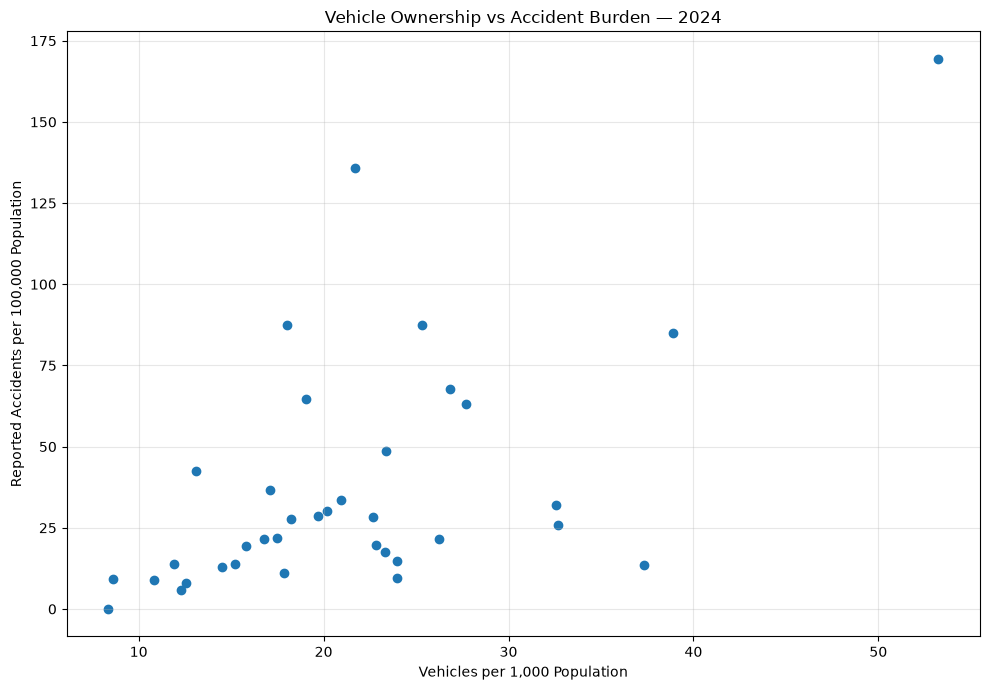

In [40]:
plt.figure(figsize=(10, 7))

plt.scatter(
    research_df["vehicles_per_1000_population"],
    research_df["accidents_per_100k_population"]
)

plt.title(
    "Vehicle Ownership vs Accident Burden — 2024"
)

plt.xlabel(
    "Vehicles per 1,000 Population"
)

plt.ylabel(
    "Reported Accidents per 100,000 Population"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [42]:
spearman_vehicle_accident = stats.spearmanr(
    research_df["vehicles_per_1000_population"],
    research_df["accidents_per_100k_population"]
)

print(
    "Spearman rho:",
    f"{spearman_vehicle_accident.statistic:.4f}"
)

print(
    "p-value:",
    f"{spearman_vehicle_accident.pvalue:.6f}"
)

Spearman rho: 0.5557
p-value: 0.000434


In [43]:
spearman_vehicle_fatality = stats.spearmanr(
    research_df["vehicles_per_1000_population"],
    research_df["fatalities_per_100k_population"]
)

print(
    "Spearman rho:",
    f"{spearman_vehicle_fatality.statistic:.4f}"
)

print(
    "p-value:",
    f"{spearman_vehicle_fatality.pvalue:.6f}"
)

Spearman rho: 0.5526
p-value: 0.000474


In [46]:
research_correlations = pd.DataFrame({
    "relationship": [
        "Vehicle registrations vs accidents",
        "Vehicle registrations vs fatalities",
        "Vehicles per 1,000 vs accidents per 100k",
        "Vehicles per 1,000 vs fatalities per 100k"
    ],
    "pearson_r": [
        vehicle_accident_corr,
        vehicle_fatality_corr,
        vehicle_rate_accident_rate_corr,
        vehicle_rate_fatality_rate_corr
    ],
    "spearman_rho": [
        np.nan,
        np.nan,
        spearman_vehicle_accident.statistic,
        spearman_vehicle_fatality.statistic
    ],
    "spearman_p_value": [
        np.nan,
        np.nan,
        spearman_vehicle_accident.pvalue,
        spearman_vehicle_fatality.pvalue
    ]
})

display(research_correlations)

,relationship,pearson_r,spearman_rho,spearman_p_value
0,Vehicle registrations vs accidents,0.782305,NaN,NaN
1,Vehicle registrations vs fatalities,0.956776,NaN,NaN
2,"Vehicles per 1,000 vs accidents per 100k",0.596790,0.555727,0.000434
3,"Vehicles per 1,000 vs fatalities per 100k",0.455479,0.552638,0.000474


In [47]:
research_correlation_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_exposure_correlations_2024.csv"
)

research_correlations.to_csv(
    research_correlation_path,
    index=False
)

print(
    "Correlation results saved to:"
)

print(research_correlation_path)

Correlation results saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\vehicle_exposure_correlations_2024.csv


In [48]:
print(
    "Vehicles/1000 vs accidents/100k — Spearman rho:",
    f"{spearman_vehicle_accident.statistic:.4f}"
)

print(
    "p-value:",
    f"{spearman_vehicle_accident.pvalue:.6f}"
)

print(
    "Vehicles/1000 vs fatalities/100k — Spearman rho:",
    f"{spearman_vehicle_fatality.statistic:.4f}"
)

print(
    "p-value:",
    f"{spearman_vehicle_fatality.pvalue:.6f}"
)

Vehicles/1000 vs accidents/100k — Spearman rho: 0.5557
p-value: 0.000434
Vehicles/1000 vs fatalities/100k — Spearman rho: 0.5526
p-value: 0.000474


## Vehicle Exposure — Preliminary Findings

Vehicle registrations show strong positive associations with absolute
reported accident and fatality counts across States/UTs.

After population normalization, the relationships become weaker but remain
positive.

Vehicles per 1,000 population have a moderate positive Pearson correlation
with reported accidents per 100,000 population (r = 0.5968). The corresponding
Spearman correlation is also positive (rho = 0.5557, p = 0.000434).

Vehicles per 1,000 population have a weaker Pearson correlation with reported
fatalities per 100,000 population (r = 0.4555), while the Spearman correlation
is moderate (rho = 0.5526, p = 0.000474).

These results suggest that vehicle ownership is associated with State/UT
variation in road-safety outcomes, but vehicle ownership alone does not fully
explain differences in accident or fatality burden.

The relationships are observational and State/UT-level. Registered vehicles
are an exposure proxy and do not directly measure traffic volume or
vehicle-kilometres travelled. Therefore, these findings should not be
interpreted as causal effects.